# Additional analyses

This jupyter porvides complementary analyses of the Einstien Telescope and the Mock Data Challenge.

## Analyses :
- PSD plots of the different GW detection instruments from pycbc.psd.analytical :

$\texttt{instruments\_PSD}$ from `fonctions.py`.

- BBH signals comparison in time and frequency domains with a modified parameter :

$\texttt{comparison\_signals\_params}$ from `fonctions.py`.

- Plot of the likelihood ratio for all the parameters used during the maxmimization process :

$\texttt{likelihood\_visualisation}$ from `fonctions.py`.

In [1]:
import sys
from likelihood import MDCGaussianNoise, subtract_signal
from pycbc.conversions import mchirp_from_mass1_mass2, mass1_from_mchirp_q, mass2_from_mchirp_q
from pycbc.types import FrequencySeries
from plot_results import convert_signal, comparison_signals, comparison_freq, qtrans_plot, gwpy_to_pycbc, pycbc_to_gwpy
sys.path.append('/home/victor-glorieux/Internship_Victor_CBC_ET')
sys.path.append('/home/victor/Internship_Victor_CBC_ET')
from fonctions import instruments_PSD, antenna_factors, comparison_signals_params, likelihood_visualisation
from generation_signal import generation_signal_GW
from generate_data import generate_frequency_domain_signal
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

/home/victor/miniconda3/envs/pycbc_env/lib/python3.9/site-packages/pycbc/inference/models/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points as _iter_entry_points


#### PSD plots :

In [ ]:
dict = {'aLigo' : 'aLIGOAPlusDesignSensitivityT1800042',
        'aVirgo' : 'AdvVirgo',
        'ET (complete)' : 'EinsteinTelescopeP1600143'}

instruments_PSD(dict,ET_MDC = True)

#### BBH signals comparison :

In [ ]:
cbc_params = {
              'mass1': 38.6,
              'mass2': 29.3,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': 1.37, 'dec': -1.26, 'distance': 500, 
              'polarization': 2.76, 'inclination': 0,
              'tc': 3.1 , 'coa_phase': 0.3,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5
                }

ifos=['E1', 'E2', 'E3']
signal = generate_frequency_domain_signal(cbc_params, ifos=ifos)
print(signal)
ts_signal = {}
psds = {}
psd_file = '../input/ET10km_columns.txt'
psd = np.loadtxt(psd_file, usecols=(0,3))
psd_of_f = interp1d(psd[:,0], psd[:,1], bounds_error=False, fill_value=(psd[0,1], psd[-1,1]))

for ifo in ifos :
    ts_signal[ifo] = signal[ifo].to_timeseries()

    freq_array = signal[ifo].get_sample_frequencies()
    delta_f = signal[ifo].get_delta_f()
    psd_pycbc = psd_of_f(freq_array)
    psd_pycbc = FrequencySeries(psd_pycbc, delta_f=delta_f)
    psds[ifo] = psd_pycbc


model = MDCGaussianNoise(signal, psds)


mass1 = {'param' : 'mass1', 'A' : 10}
spins = {'param' : 'spin1z', 'A' : 1, 'B' : 0, 'C' : -1}
# mchirp = {'A' : round(mchirp_from_mass1_mass2(mass1['A'],mass2),1),'B' : round(mchirp_from_mass1_mass2(mass1['B'],mass2),1),
#           'C' : round(mchirp_from_mass1_mass2(mass1['C'],mass2),2)}

comparison_signals_params(model,mass1,cbc_params)


#### Plot of the likelihood ratio :

Iterations totales :  629


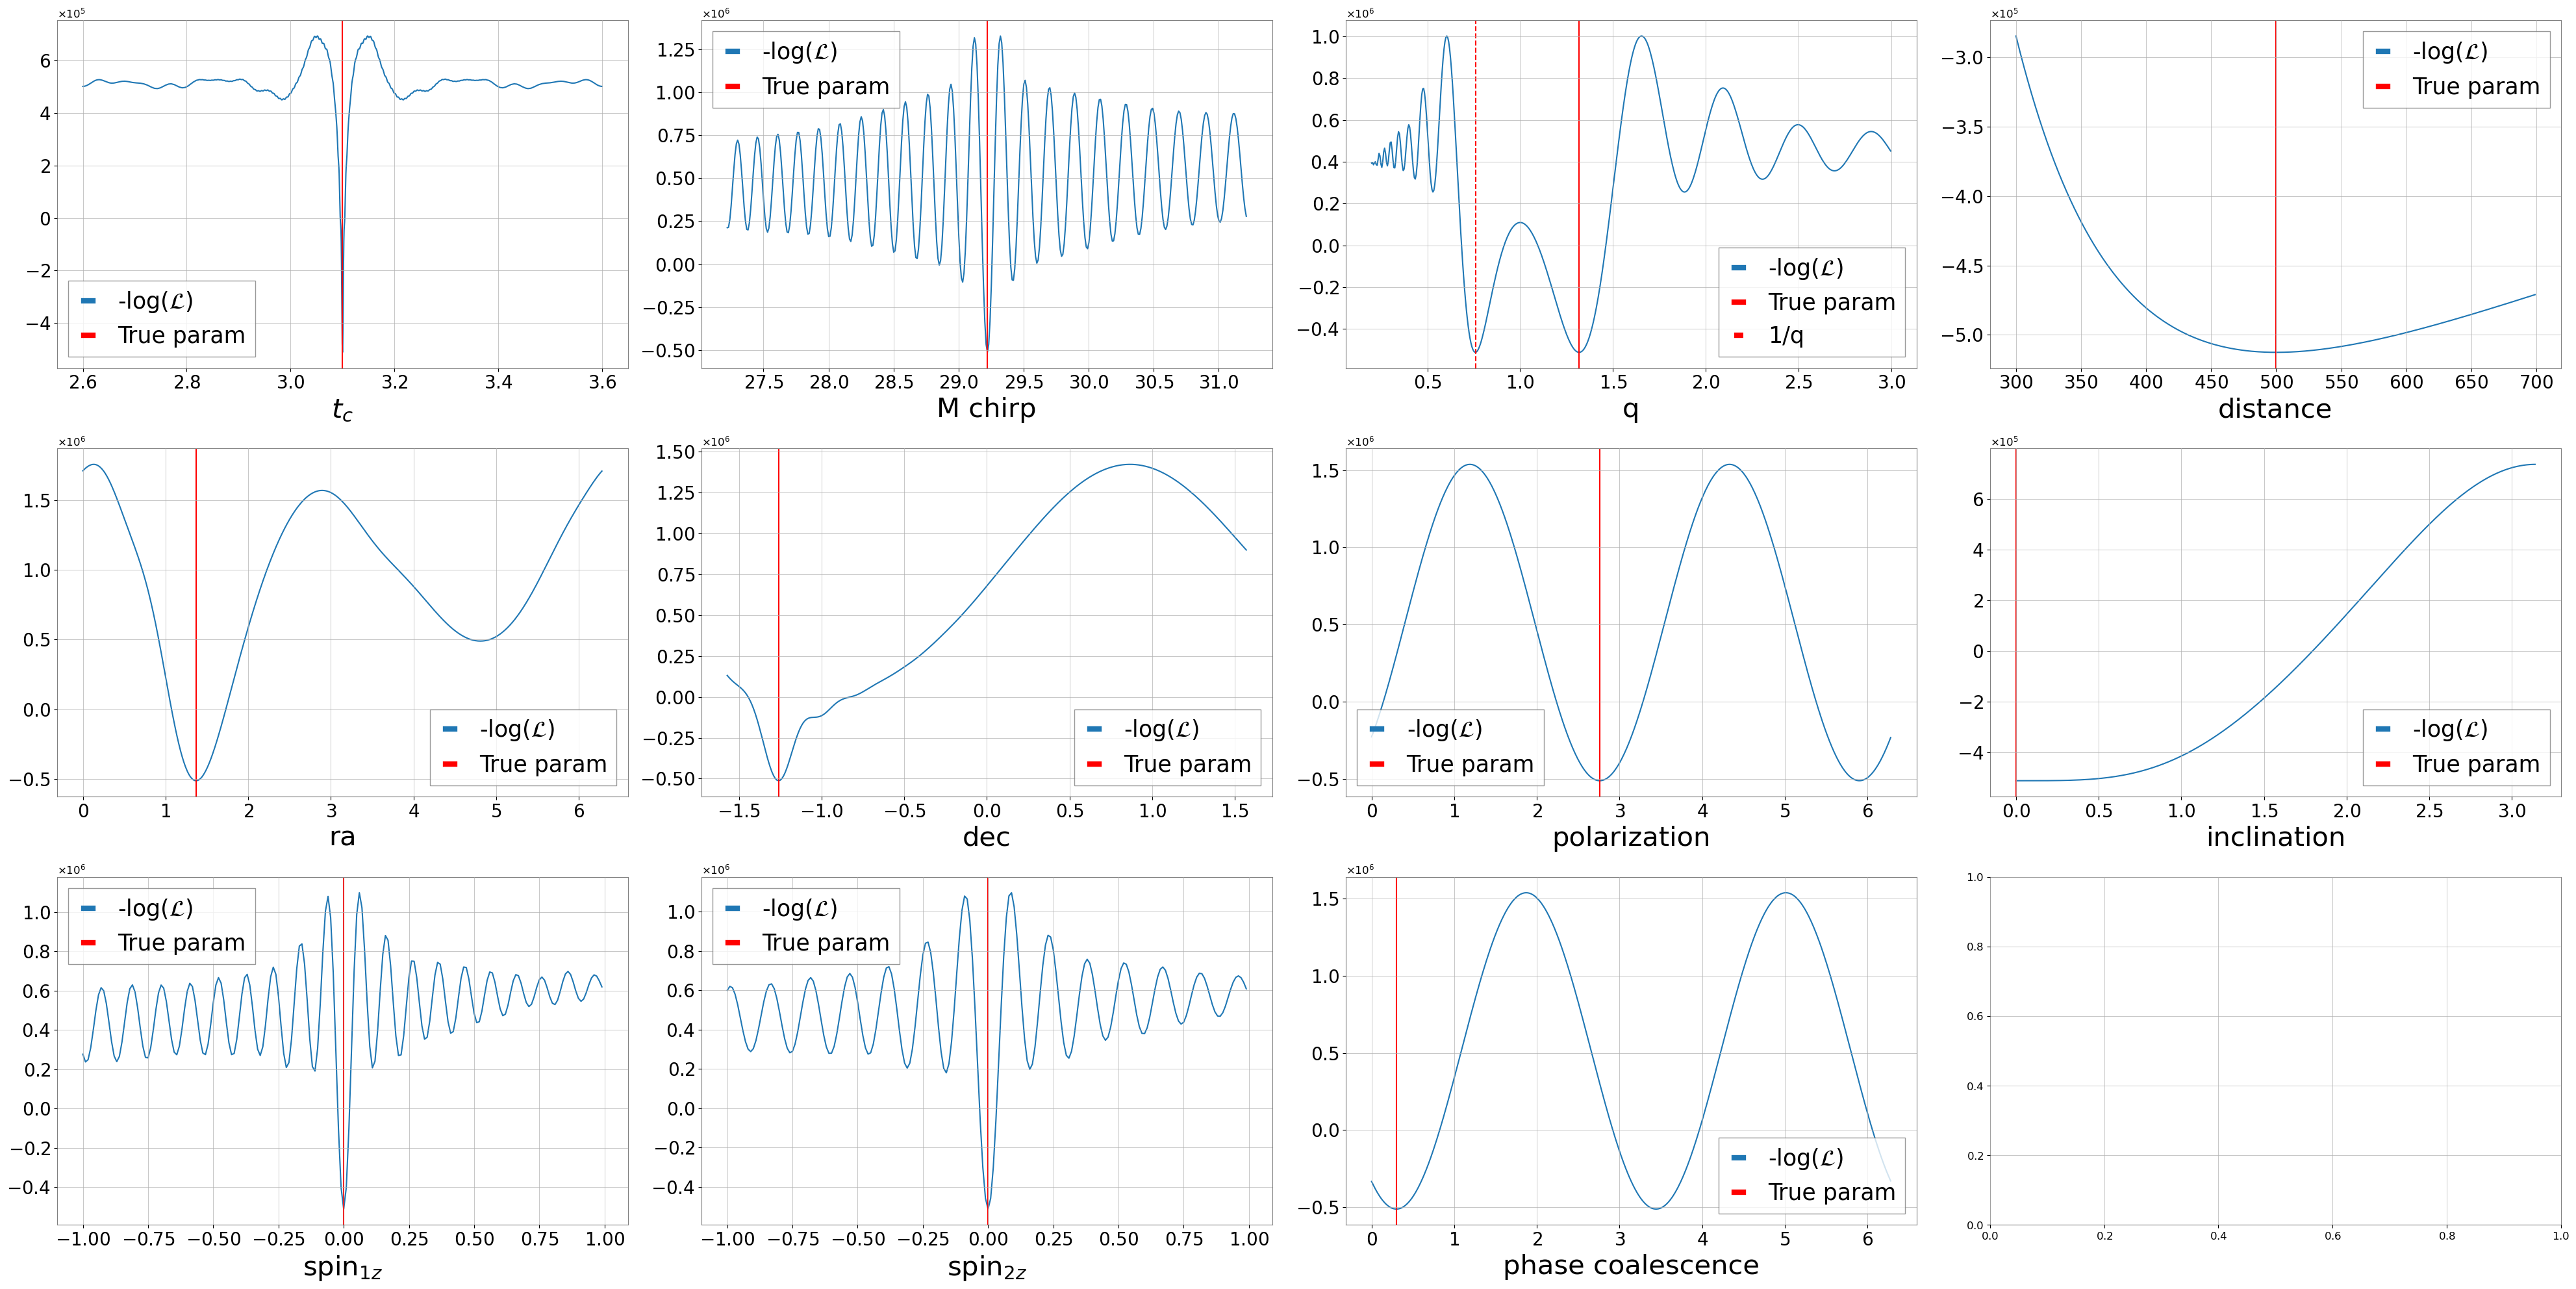

In [2]:
cbc_params = {
              'mass1': 38.6,
              'mass2': 29.3,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': 1.37, 'dec': -1.26, 'distance': 500, 
              'polarization': 2.76, 'inclination': 0,
              'tc': 3.1 , 'coa_phase': 0.3,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5
                }

ifos=['E1', 'E2', 'E3']
signal = generate_frequency_domain_signal(cbc_params, ifos=ifos)
print(signal)
ts_signal = {}
psds = {}
psd_file = '../input/ET10km_columns.txt'
psd = np.loadtxt(psd_file, usecols=(0,3))
psd_of_f = interp1d(psd[:,0], psd[:,1], bounds_error=False, fill_value=(psd[0,1], psd[-1,1]))

for ifo in ifos :
    ts_signal[ifo] = signal[ifo].to_timeseries()

    freq_array = signal[ifo].get_sample_frequencies()
    delta_f = signal[ifo].get_delta_f()
    psd_pycbc = psd_of_f(freq_array)
    psd_pycbc = FrequencySeries(psd_pycbc, delta_f=delta_f)
    psds[ifo] = psd_pycbc


model = MDCGaussianNoise(signal, psds)

likelihood_visualisation(model,cbc_params)